# Impute Missing Data and Research Question
- Author: Bryan Bravo
- Created: 2026-04-07
## Research Question:
Using crude oil spot prices, the Liner Shipping Connectivity Index (LSCI), global political violence events, and a geopolitical risk index, can we accurately estimate a country's foreign exchange (FX) reserves and its imports of goods and services using a Random Forest Regressor?

### Selected Variables
#### Relative (Target) Variable:
- **fx_reserves**: Continuous Variable
- **imports_good_service**: Continuous Variable

#### Explanatory Variables:
- **country**: Categorical Variable
- **date**: Categorical Variable
- **interest_rate**: Continuous Variable
- **fx_rate**: Continuous Variable
- **brent_dollars_per_barrel**: Continuous Variable
- **wti_dollars_per_barrel**: Continuous Variable
- **events**: Continuous Variable
- **cpi**: Continuous Variable
- **gpr_index**: Continuous Variable
- **lsci**: Continuous Variable

## Import Libraries

In [1]:
import os
import sys

os.chdir("C:/Users/bravo/OneDrive/bravo_projects/MLProject/StraitofHormuzResearch")
# Set JAVA_HOME before importing PySpark and use findspark
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-22'  # May need to remove or update in cloud environment.
import findspark
findspark.init()

import requests
import pandas as pd
import numpy as np
import json
import pyspark
from datetime import datetime as dt
from dateutil.relativedelta import relativedelta
from functools import reduce
from pyspark.sql import (
    functions as F,
    Window as W,
    types as T,
    SparkSession,
    DataFrame
)

# Visualize data for joined dataframes.
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn libraries and packages
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

# api keys and other hardcoded values for the Strait of Hormuz Research project.
# Note: In a production environment, these should be stored securely and not hardcoded.
import hardcoded_keys # Note: This file is added to .gitignore to prevent accidental commits of sensitive information.

import proj_vars

### Initialize Spark Session


In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BusinessPlanAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.hadoop.io.native.lib.available", "false") \
    .config("spark.sql.parquet.nativeio.enabled", "false") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


## Variables

In [3]:
end_date = (dt.now().replace(day=1) - relativedelta(days=1)).strftime("%Y-%m-%d")
# in_path = 's3a://ml-project-s3-bronze/input_folder/'
in_path = 'processed_datasets/'
out_path = 'processed_datasets/'


## User Defined Functions 

# Query

In [4]:
# Import dataset
joined_df = spark.read.csv(in_path + 'joined_input.csv', header=True, inferSchema=True)
joined_df = joined_df.withColumn('date', F.to_date(F.col('date'), 'yyyyMMdd'))

In [5]:
# # Create separate dataframes for each country
# country_list = joined_df.select(F.col('country')).distinct().toPandas()['country'].tolist()
# country_dct = {f"{country}_df": joined_df.filter(F.col('country').contains(country)) 
#                for country in country_list}
# [*country_dct.keys()]

In [6]:
joined_df.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60276 entries, 0 to 60275
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      60276 non-null  int32  
 1   month                     60276 non-null  int32  
 2   country                   60276 non-null  object 
 3   date                      60276 non-null  object 
 4   interest_rate             60276 non-null  float64
 5   fx_rate                   60276 non-null  float64
 6   brent_dollars_per_barrel  60276 non-null  float64
 7   wti_dollars_per_barrel    60276 non-null  float64
 8   events                    60276 non-null  int32  
 9   cpi                       60276 non-null  float64
 10  gpr_index                 60276 non-null  float64
 11  lsci                      60276 non-null  float64
 12  fx_reserves               55596 non-null  float64
 13  imports_good_service      55596 non-null  float64
dtypes: flo

## Data Wrangling
### One-hot encode `country`, `month` variables, and add a one-hot encoded variable for day-of-week.


In [7]:
# Extract country values
country_list = joined_df.select(F.col('country')).distinct().toPandas()['country'].tolist()

wrangled_df = (
    joined_df
    .withColumns({  # One-hot encode country column
        f"{country}_n": F.when(F.col('country').contains(country), F.lit(1)).otherwise(F.lit(0)) for country in country_list
    })
    .withColumns({  # One-hot encode month column
        f"month_{i}": F.when(F.col('month') == i, F.lit(1)).otherwise(F.lit(0)) for i in range(1, 13)
    })
    .withColumns({  # Generate a day of week one-hot encoding (1-7, where 1 = Sunday and 7 = Saturday)
        f'dow_{i}': F.when(F.dayofweek(F.col('date')) == i, F.lit(1)).otherwise(F.lit(0)) for i in range(1, 8)
    })
    .drop('country', 'month', 'date')
)

wrangled_null_response_df = (  # Isolating rows where response variables are null. Expected 4680 rows.
    wrangled_df.filter(F.col('fx_reserves').isNull() & F.col('imports_good_service').isNull())
).toPandas()

wrangled_df = (  # Will split train test with this dataset.
    wrangled_df.filter(F.col('fx_reserves').isNotNull() & F.col('imports_good_service').isNotNull())
).toPandas()
print("wrangled_df:", wrangled_df.shape)
print("wrangled_null_response_df:", wrangled_null_response_df.shape)

wrangled_df: (55596, 46)
wrangled_null_response_df: (4680, 46)


In [8]:
wrangled_df.head()

,year,interest_rate,fx_rate,brent_dollars_per_barrel,wti_dollars_per_barrel,events,cpi,gpr_index,lsci,fx_reserves,...,month_10,month_11,month_12,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,dow_7
0,2006,5.728261,0.7519,67.57,71.42,0,84.5,0.062846,141.65,49615.006093,...,0,0,0,0,0,0,1,0,0,0
1,2006,5.728261,0.7619,69.82,71.85,0,84.5,0.062846,141.65,49615.006093,...,0,0,0,0,0,1,0,0,0,0
2,2006,5.728261,0.7577,69.88,71.35,0,84.5,0.062846,141.65,49615.006093,...,0,0,0,0,0,0,0,0,1,0
3,2006,5.728261,0.7585,68.51,70.92,0,84.5,0.062846,141.65,49615.006093,...,0,0,0,0,0,0,0,1,0,0
4,2006,5.728261,0.7526,68.45,69.47,0,84.5,0.062846,141.65,49615.006093,...,0,0,0,0,0,0,1,0,0,0


### Feature Selection using SelectKBest
`fx_reserves` response variable

In [9]:
# Define variables
response_var = 'fx_reserves'
explanatory_var = [var for var in wrangled_df.columns if var not in ['fx_reserves', 'imports_good_service']]

# Assign values
X = wrangled_df[explanatory_var]
y = wrangled_df[response_var]
X.shape, y.shape

((55596, 44), (55596,))

In [10]:
# Use SelectKBest and use the fit_transform method.
skbest = SelectKBest(k='all', score_func=f_regression)
X_skbest = skbest.fit_transform(X, y)
X_skbest.shape

(55596, 44)

In [11]:
# Finding p-values and dataframe creation.
pval_df = pd.DataFrame({
    'Feature': X.columns,
    'p_value': skbest.pvalues_
}).sort_values('p_value')

# Selected Features
pval_pf = pval_df[pval_df["p_value"] < 0.05]
fx_reserves_selected_features = pval_pf['Feature'].tolist()  # extract selected feature list.
print("fx_reserves selected feature count: ", len(fx_reserves_selected_features))
pval_pf.style.format({'Feature': '{}', 'p_value': '{:.5f}'})

fx_reserves selected feature count:  24


,Feature,p_value
8,lsci,0.00000
12,china_n,0.00000
11,japan_n,0.00000
18,south_africa_n,0.00000
13,australia_n,0.00000
16,france_n,0.00000
10,canada_n,0.00000
22,united_kingdom_n,0.00000
2,fx_rate,0.00000
24,united_states_n,0.00000


`imports_good_service` response variable

In [12]:
# Define variables
response_var = 'imports_good_service'
explanatory_var = [var for var in wrangled_df.columns if var not in ['fx_reserves', 'imports_good_service']]

# Assign values
X = wrangled_df[explanatory_var]
y = wrangled_df[response_var]
X.shape, y.shape

((55596, 44), (55596,))

In [13]:
# Use SelectKBest and use the fit_transform method.
skbest = SelectKBest(k='all', score_func=f_regression)
X_skbest = skbest.fit_transform(X, y)
X_skbest.shape

(55596, 44)

In [14]:
# Finding p-values and dataframe creation.
pval_df = pd.DataFrame({
    'Feature': X.columns,
    'p_value': skbest.pvalues_
}).sort_values('p_value')

# Selected Features
pval_pf = pval_df[pval_df["p_value"] < 0.05]
imports_good_service_selected_features = pval_pf['Feature'].tolist()  # extract selected feature list.
print("imports_good_service selected feature count: ", len(imports_good_service_selected_features))
pval_pf.style.format({'Feature': '{}', 'p_value': '{:.5f}'})

imports_good_service selected feature count:  25


,Feature,p_value
0,year,0.00000
1,interest_rate,0.00000
2,fx_rate,0.00000
24,united_states_n,0.00000
6,cpi,0.00000
7,gpr_index,0.00000
8,lsci,0.00000
9,brazil_n,0.00000
12,china_n,0.00000
13,australia_n,0.00000


# Machine Learning
## `fx_reserves`
### Train/Test Split

In [ ]:
# Define Variables
response_var = 'fx_reserves'
explanatory_var = fx_reserves_selected_features

# Assign values
X = wrangled_df[explanatory_var]
y = wrangled_df[response_var]

seed = 2026

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=seed)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((44476, 24), (11120, 24), (44476,), (11120,))

### Random Forest Regression Model for `fx_reserves`

In [16]:
# Instantiate Random Forest Regressor
rf = RandomForestRegressor(random_state=seed)

# Instantiate KFold for cross_validation
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 2026,
 'verbose': 0,
 'warm_start': False}

In [25]:
# Define a grid of hyperparameters
params = {
    'n_estimators': np.arange(50, 100, 25),  # Number of trees
    'max_depth': np.arange(5, 50),  # The maximum depth of the tree
    'max_features': ['log2', 'sqrt']  # Amount of features to consider when looking to split
}

# Instantiate GridSearchCV
grid_rf = GridSearchCV(estimator=rf,
                       param_grid=params,
                       cv=kf,
                       scoring='neg_mean_squared_error',
                       n_jobs=-1)

# Fit Training set
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...om_state=2026)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 5, 6..., 47, 48, 49]), 'max_features': ['log2', 'sqrt'], 'n_estimators': array([50, 75])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computa

In [26]:
# Extract Best Score
best_score = grid_rf.best_score_
print(f'Best Negative MSE Score: {best_score:.2f}')

# Extract the best hyperparameters
best_hyperparams = grid_rf.best_params_
print(f'Best Hyperparameters: \n {best_hyperparams} \n')

# Extract the best model
final_mdl = grid_rf.best_estimator_
final_mdl

Best Negative MSE Score: -11794745.56
Best Hyperparameters: 
 {'max_depth': np.int64(30), 'max_features': 'log2', 'n_estimators': np.int64(75)} 



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",np.int64(75)
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(30)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is

#### Feature Importance

Features Importances: 
 lsci                0.371598
china_n             0.240877
fx_rate             0.160021
interest_rate       0.075066
cpi                 0.038662
japan_n             0.037776
gpr_index           0.019009
year                0.017244
france_n            0.008824
south_africa_n      0.006438
south_korea_n       0.005676
united_kingdom_n    0.004752
australia_n         0.003447
india_n             0.003194
canada_n            0.002554
united_states_n     0.002329
brazil_n            0.001043
mexico_n            0.000864
germany_n           0.000227
events              0.000144
italy_n             0.000118
turkiye_n           0.000081
dow_7               0.000035
dow_1               0.000020
dtype: float64


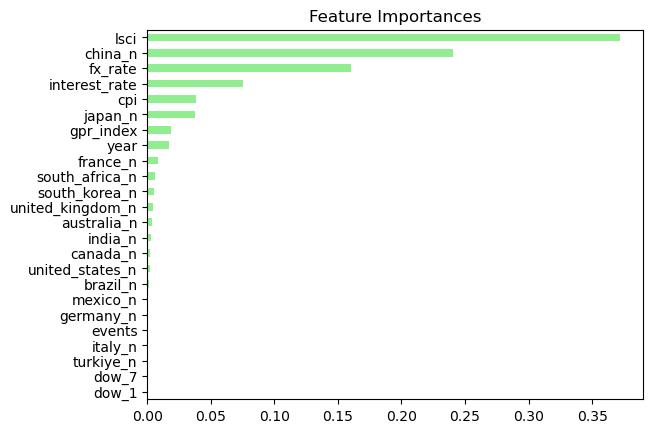

In [27]:
# Create a Series of features importances
importances_rf = pd.Series(final_mdl.feature_importances_,
                          index=X_train.columns).sort_values()
print(f'Features Importances: \n', importances_rf.sort_values(ascending=False))

# Visualize
importances_rf.plot(kind='barh', color='lightgreen')
plt.title('Feature Importances')
plt.show()